In [1]:
from google.colab import files

files.upload()

Saving Kaggle Settings.json to Kaggle Settings.json


{'Kaggle Settings.json': b'{"username":"pradeesh11","key":"6f79c79f31ff5be9e5e6a6d2e323b156"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp "Kaggle Settings.json" ~/.kaggle/
!chmod 600 ~/.kaggle/"Kaggle Settings.json"

In [6]:
!kaggle datasets download -d spscientist/students-performance-in-exams

Dataset URL: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
License(s): unknown
100% 8.70k/8.70k [00:00<00:00, 16.8MB/s]



In [7]:
!unzip students-performance-in-exams.zip


Archive:  students-performance-in-exams.zip
  inflating: StudentsPerformance.csv  


LINEAR REGRESSION CODE
Predicting Math Score using Reading Score

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Model Training Completed

Evaluation Metrics
---------------------
MAE  : 7.28
MSE  : 77.76
RMSE : 8.82
R2   : 0.68

Model Parameters
---------------------
Sl

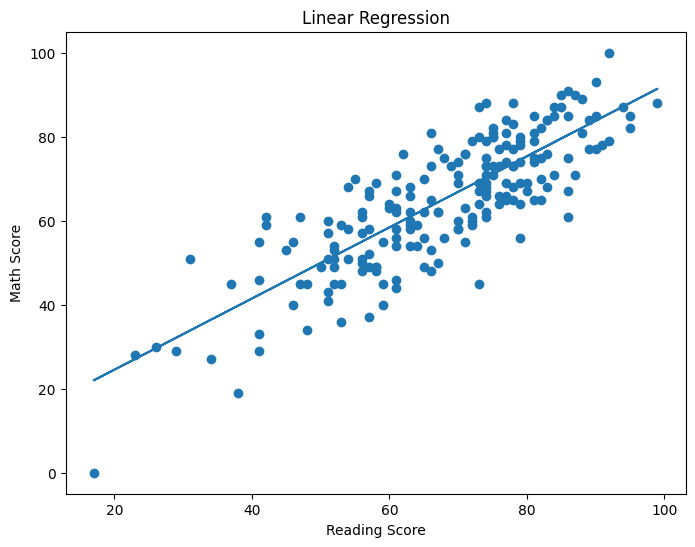

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("StudentsPerformance.csv")

print(df.head())

X = df[["reading score"]]
y = df["math score"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("---------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.2f}")


print("\nModel Parameters")
print("---------------------")

print(f"Slope      : {model.coef_[0]:.2f}")
print(f"Intercept  : {model.intercept_:.2f}")


plt.figure(figsize=(8, 6))

plt.scatter(
    X_test,
    y_test
)

plt.plot(
    X_test,
    y_pred
)

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Linear Regression")

plt.show()

MULTIPLE LINEAR REGRESSION CODE
Predicting Math Score using Multiple Features

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("StudentsPerformance.csv")

print(df.head())

label_encoder = LabelEncoder()

categorical_columns = [
    "gender",
    "lunch",
    "parental level of education"
]

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])


X = df[
    [
        "reading score",
        "writing score",
        "gender",
        "lunch",
        "parental level of education"
    ]
]

y = df["math score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()


model.fit(X_train, y_train)

print("\nModel Training Completed")

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("---------------------")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.2f}")


print("\nFeature Coefficients")
print("---------------------")

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature} : {coef:.2f}")

print(f"\nIntercept : {model.intercept_:.2f}")

sample_data = pd.DataFrame({
    "reading score": [80],
    "writing score": [85],
    "gender": [1],
    "lunch": [1],
    "parental level of education": [2]
})

prediction = model.predict(sample_data)

print("\nPredicted Math Score")
print("---------------------")

print(prediction[0])

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Model Training Completed

Evaluation Metrics
---------------------
MAE  : 4.49
MSE  : 32.61
RMSE : 5.71
R2   : 0.87

Feature Coefficients
--------------------